# Modèle 3 — XGBoost

XGBoost (eXtreme Gradient Boosting) est généralement le modèle le plus performant
sur les datasets tabulaires. Contrairement au Random Forest qui construit des arbres
en parallèle, XGBoost les construit séquentiellement : chaque arbre corrige les erreurs
du précédent (boosting par gradient).

**Avantages :** très performant, régularisation intégrée (L1/L2), gère les données déséquilibrées  
**Limites :** plus d'hyperparamètres à tuner, moins intuitif à interpréter

In [6]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

from src.data.loader import PROCESSED_DIR
from src.evaluation.metrics import (
    compute_classification_metrics, print_classification_report,
    plot_roc_curve, plot_confusion_matrix, plot_feature_importance
)
from src.models.mlflow_utils import setup_mlflow, log_classification_run, EXPERIMENT_CHURN

plt.rcParams['figure.dpi'] = 110

X_train = pd.read_csv(PROCESSED_DIR / 'X_train.csv')
X_test = pd.read_csv(PROCESSED_DIR / 'X_test.csv')
y_train = pd.read_csv(PROCESSED_DIR / 'y_train.csv').squeeze()
y_test = pd.read_csv(PROCESSED_DIR / 'y_test.csv').squeeze()
feature_names = joblib.load(PROCESSED_DIR / 'feature_names.joblib')

# Calcul du poids des classes pour gérer le déséquilibre
# scale_pos_weight = n_négatifs / n_positifs est le paramètre XGBoost dédié
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
scale_pos_weight = n_neg / n_pos
print(f"scale_pos_weight = {scale_pos_weight:.2f} (ratio négatifs/positifs)")

scale_pos_weight = 8.79 (ratio négatifs/positifs)


## 1. Entraînement

In [7]:
# scale_pos_weight équivaut à augmenter le poids des churners dans la loss.
# C'est l'équivalent XGBoost de class_weight='balanced' dans sklearn.
# learning_rate=0.1 avec 300 arbres est un compromis courant pour ce type de dataset.
# subsample et colsample_bytree sont des techniques de régularisation
# qui réduisent le risque d'overfitting en tirant des sous-échantillons aléatoires.
model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='auc',
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50,
)
print("Entraînement terminé.")

[0]	validation_0-auc:0.71981
[50]	validation_0-auc:0.79101
[100]	validation_0-auc:0.78349
[150]	validation_0-auc:0.78287
[200]	validation_0-auc:0.77379
[250]	validation_0-auc:0.76754
[299]	validation_0-auc:0.76614
Entraînement terminé.


## 2. Évaluation

In [8]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

metrics = compute_classification_metrics(y_test.values, y_pred, y_proba)
print_classification_report(y_test, y_pred, 'XGBoost')

print("\nMétriques :")
for k, v in metrics.items():
    print(f"  {k} : {v:.4f}")


Rapport de classification — XGBoost
--------------------------------------------------
              precision    recall  f1-score   support

   Non-Churn       0.91      0.94      0.93      1796
       Churn       0.29      0.22      0.25       204

    accuracy                           0.87      2000
   macro avg       0.60      0.58      0.59      2000
weighted avg       0.85      0.87      0.86      2000


Métriques :
  accuracy : 0.8660
  auc_roc : 0.7661
  f1_weighted : 0.8572
  f1_churn : 0.2472
  precision_churn : 0.2895
  recall_churn : 0.2157
  log_loss : 0.3272


In [9]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_auc = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
print(f"AUC-ROC CV (5 plis) : {cv_auc.mean():.4f} ± {cv_auc.std():.4f}")

AUC-ROC CV (5 plis) : 0.7631 ± 0.0178


## 3. Visualisations

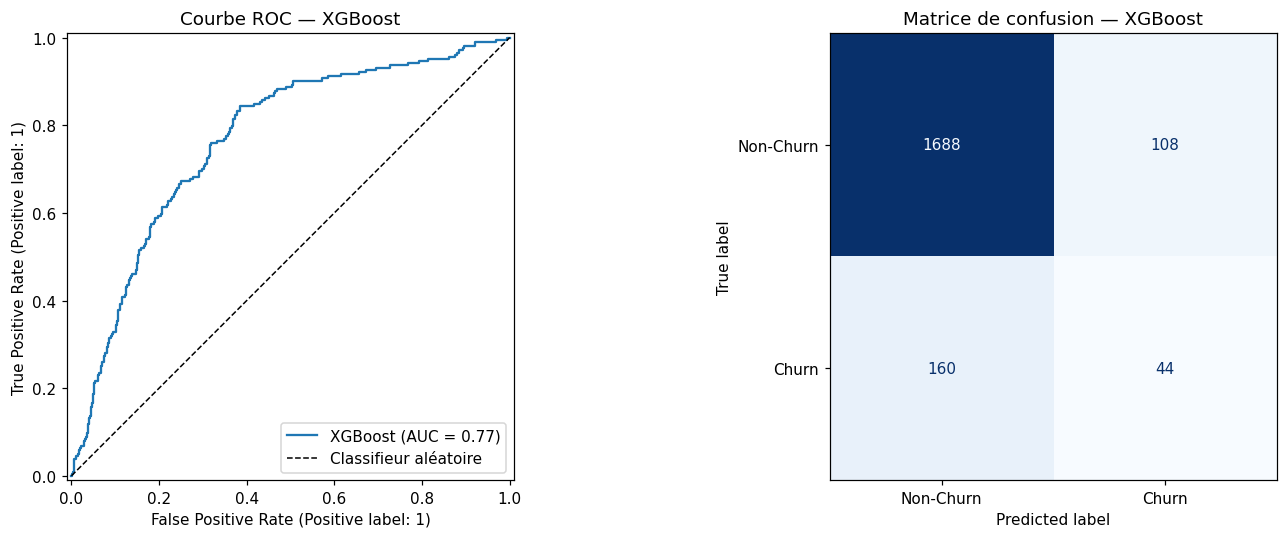

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_roc_curve(model, X_test, y_test, 'XGBoost', ax=axes[0])
plot_confusion_matrix(y_test, y_pred, 'XGBoost', ax=axes[1])
plt.tight_layout()
plt.savefig('../data/processed/fig_xgboost_roc_cm.png', bbox_inches='tight')
plt.show()

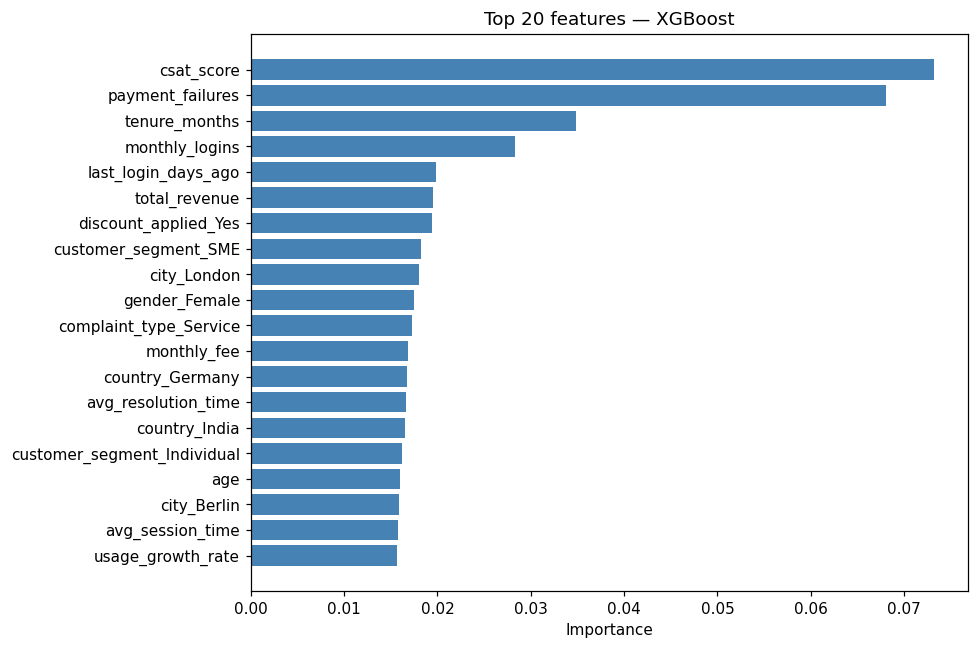

In [11]:
fig = plot_feature_importance(
    model.feature_importances_, feature_names, 'XGBoost', top_n=20
)
plt.savefig('../data/processed/fig_xgboost_importance.png', bbox_inches='tight')
plt.show()

## 4. Enregistrement MLflow

In [12]:
setup_mlflow(EXPERIMENT_CHURN)

params = {
    'n_estimators': model.n_estimators,
    'learning_rate': model.learning_rate,
    'max_depth': model.max_depth,
    'subsample': model.subsample,
    'colsample_bytree': model.colsample_bytree,
    'scale_pos_weight': float(scale_pos_weight),
    'cv_auc_mean': float(cv_auc.mean()),
    'cv_auc_std': float(cv_auc.std()),
}

run_id = log_classification_run(
    model=model,
    model_name='XGBoost',
    params=params,
    metrics=metrics,
    X_train=X_train,
    X_test=X_test,
    y_test=y_test,
    feature_names=feature_names,
)

joblib.dump(model, PROCESSED_DIR / 'model_xgboost.joblib')
print(f"Run MLflow : {run_id}")

Expérience MLflow : 'churn_classification' (id=1)
Run enregistré : XGBoost | run_id=e0b968115d5b40b4b4ca3a56f47a602e
  AUC-ROC : 0.7661
  F1 (classe 1) : 0.2472
🏃 View run XGBoost at: http://localhost:5000/#/experiments/1/runs/e0b968115d5b40b4b4ca3a56f47a602e
🧪 View experiment at: http://localhost:5000/#/experiments/1
Run MLflow : e0b968115d5b40b4b4ca3a56f47a602e


In [13]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# Espace de recherche : on explore des combinaisons aléatoires plutôt qu'une grille complète.
# RandomizedSearch est préféré à GridSearch ici car XGBoost a de nombreux hyperparamètres
# et la grille complète serait trop coûteuse (temps de calcul vs valeur pédagogique).
param_dist = {
    'n_estimators': randint(50, 200),
    'max_depth': randint(3, 8),
    'learning_rate': uniform(0.05, 0.2),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'min_child_weight': randint(1, 6),
}

xgb_base = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    eval_metric='auc',
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)

cv_strat = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    xgb_base,
    param_distributions=param_dist,
    n_iter=20,
    scoring='roc_auc',
    cv=cv_strat,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

search.fit(X_train, y_train)

print(f"Meilleurs hyperparamètres trouvés :")
for k, v in search.best_params_.items():
    print(f"  {k} : {v}")
print(f"\nMeilleur AUC-ROC CV (3 plis) : {search.best_score_:.4f}")

# Évaluation du modèle optimisé sur le jeu de test
best_xgb = search.best_estimator_
y_pred_opt = best_xgb.predict(X_test)
y_proba_opt = best_xgb.predict_proba(X_test)[:, 1]
metrics_opt = compute_classification_metrics(y_test.values, y_pred_opt, y_proba_opt)
print(f"\nAUC-ROC test (modèle optimisé) : {metrics_opt['auc_roc']:.4f}")
print(f"AUC-ROC test (modèle de base)   : {metrics['auc_roc']:.4f}")
print(f"Gain : {metrics_opt['auc_roc'] - metrics['auc_roc']:+.4f}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Meilleurs hyperparamètres trouvés :
  colsample_bytree : 0.8446612641953124
  learning_rate : 0.05141326104394348
  max_depth : 3
  min_child_weight : 1
  n_estimators : 108
  subsample : 0.7599443886861021

Meilleur AUC-ROC CV (3 plis) : 0.8065

AUC-ROC test (modèle optimisé) : 0.8142
AUC-ROC test (modèle de base)   : 0.7661
Gain : +0.0481


## 5. Optimisation des hyperparamètres — RandomizedSearchCV

On remarque que l'AUC a atteint un pic à l'époque 50 puis a décliné jusqu'à 299,
ce qui est un signe clair de surapprentissage. Une recherche aléatoire d'hyperparamètres
permet d'identifier les valeurs qui équilibrent mieux biais et variance.